# Machine Learning Classifier

In this notebook, features will be created to train a Machine Learning classifier to predict the similarity between each pair of claims. A simple approach will be used without further tuning.

In [1]:
# Feature Extraction for Claim Matching

import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
import spacy
from sklearn.metrics.pairwise import cosine_similarity
from datetime import datetime
from dateutil.parser import parse as parse_date
from rapidfuzz import fuzz

from transformers import AutoTokenizer
from sentence_transformers import CrossEncoder
from langdetect import detect
from keybert import KeyBERT


EMB_MODEL_NAME = "intfloat/multilingual-e5-large"
CE_MODEL_NAME = "cross-encoder/nli-deberta-v3-large"

In [2]:
df = pd.read_csv("nbs/other/claim_matching_dataset.csv")
# df = df.fillna("")
df["unverified claim"] = df["unverified claim"].fillna("")
df["reviewed claim"] = df["reviewed claim"].fillna("")
# df["summary"] = df["summary"].fillna("")


# Load pretrained models

In [3]:
# Load NLP model for linguistic features
nlp = spacy.load("xx_ent_wiki_sm")  # multilingual model

# Load sentence embedding model
embedding_model = SentenceTransformer(EMB_MODEL_NAME)

# # Force slow tokenizer
# tokenizer = AutoTokenizer.from_pretrained(CE_MODEL_NAME,)

# Then load the model using CrossEncoder, passing the tokenizer manually
nli_model = CrossEncoder(
    model_name=CE_MODEL_NAME,
    # tokenizer_args={"tokenizer": tokenizer}
)

kw_model = KeyBERT(EMB_MODEL_NAME)


/gpfs/projects/bsc14/scratch/.conda/factcheck/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:559: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [4]:
from tqdm import tqdm
tqdm.pandas()

# df["unverified claim_keywords"] = df["unverified claim"].progress_apply(lambda x: kw_model.extract_keywords(x, keyphrase_ngram_range=(1, 3), stop_words=None))
def create_features(df):
    # --- Feature functions ---
    def compute_cosine_sim(text1, text2):
        if pd.isna(text1) or pd.isna(text2):
            return 0.0
        emb1 = embedding_model.encode(text1, convert_to_tensor=True)
        emb2 = embedding_model.encode(text2, convert_to_tensor=True)
        return util.cos_sim(emb1, emb2).item()

    def nli_contradiction(claim, evidence):
        return torch.tensor(nli_model.predict([(claim, evidence)])[0]).softmax(dim=0)[0].item()

    def token_overlap(text1, text2):
        tokens1 = set(str(text1).lower().split())
        tokens2 = set(str(text2).lower().split())
        return len(tokens1 & tokens2) / (len(tokens1 | tokens2) + 1e-5)

    def lang_match(text, lang):
        try:
            return int(detect(str(text)) == lang)
        except:
            return 0

    def has_negation(text):
        return int(any(tok.lower_ in ["no", "not", "nunca", "ni", "sin", "n'est", "non"] for tok in nlp(str(text))))

    def shared_named_entities(text1, text2):
        ents1 = set([ent.text.lower() for ent in nlp(str(text1)).ents])
        ents2 = set([ent.text.lower() for ent in nlp(str(text2)).ents])
        return len(ents1 & ents2)
        
    def keyword_overlap(kb_keywords, claim):
            
        try:
            if isinstance(kb_keywords, str):
                keywords = eval(kb_keywords)  # list of (kw, score)
            else:
                keywords = kb_keywords
            
            # print(keywords)
            kw_claim = kw_model.extract_keywords(claim, keyphrase_ngram_range=(1, 3), stop_words=None)
            kw_claim = [kw for kw, _ in kw_claim]
            # print(kw_claim)

            return len([k for k, _ in keywords if k in kw_claim])
        except:
            return 0


    def text_length(text):
        return len(str(text).split())

    def fuzzy_title_match(title, claim):
        return fuzz.partial_ratio(str(title), str(claim)) / 100

    feature_df = pd.DataFrame()

    # print("Extracting keywords...")
    # feature_df["unverified claim_keywords"] = df["unverified claim"].progress_apply(lambda x: kw_model.extract_keywords(x, keyphrase_ngram_range=(1, 3), stop_words=None))
    
    # --- Apply feature engineering ---

    feature_df['ft_cosine_claim_reviewed'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["reviewed claim"]), axis=1)
    feature_df['ft_cosine_claim_summary'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["summary"]), axis=1)
    feature_df['ft_cosine_claim_meta_desc'] = df.progress_apply(lambda x: compute_cosine_sim(x["unverified claim"], x["meta_description"]), axis=1)

    # Token overlap and shared named entities
    feature_df['ft_token_overlap'] = df.progress_apply(lambda x: token_overlap(x["unverified claim"], x["reviewed claim"]), axis=1)
    feature_df['ft_shared_named_entities'] = df.progress_apply(lambda x: shared_named_entities(x["unverified claim"], x["reviewed claim"]), axis=1)

    # Boolean flags (easy vectorizations)
    feature_df['ft_has_negation'] = df['unverified claim'].apply(has_negation).astype(int)
    feature_df['ft_has_negation_reviewed'] = df['reviewed claim'].apply(has_negation).astype(int)

    # Keyword overlaps
    print("Computing keyword overlaps...")

    feature_df['ft_keyword_overlap_kb'] = df.progress_apply(lambda x: keyword_overlap(x["kb_keywords"], x["unverified claim"]), axis=1)
    feature_df['ft_keyword_overlap_meta'] = df.progress_apply(lambda x: keyword_overlap(x["meta_keywords"], x["unverified claim"]), axis=1)

    # Domain match (fully vectorized)
    feature_df['ft_domain_match'] = ((df['url'].notna()) & (df.apply(lambda row: row['domain'] in row['url'], axis=1))).astype(int)

    # Language match and image/video presence
    feature_df['ft_lang_match'] = df.progress_apply(lambda x: lang_match(x["unverified claim"], x["meta_lang"]), axis=1)
    feature_df['ft_has_image'] = df['cr_image'].notna().astype(int)
    feature_df['ft_has_video'] = df['movies'].apply(lambda x: int(len(eval(x)) > 0) if pd.notna(x) else 0)

    # Text lengths
    feature_df['ft_text_len_summary'] = df['summary'].apply(text_length)
    feature_df['ft_text_len_meta'] = df['meta_description'].apply(text_length)

    # Fuzzy matching
    feature_df['ft_title_match_ratio'] = df.progress_apply(lambda x: fuzzy_title_match(x["title"], x["unverified claim"]), axis=1)


    nli_probs = nli_model.predict(df[["unverified claim", "reviewed claim"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_reviewed"] = nli_probs[:, 0]

    nli_probs = nli_model.predict(df[["unverified claim", "summary"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_summary"] = nli_probs[:, 0]

    nli_probs = nli_model.predict(df[["unverified claim", "meta_description"]].fillna("").values.tolist())
    nli_probs = torch.tensor(nli_probs).softmax(dim=1).numpy()
    feature_df["ft_contr_nli_claim_meta_desc"] = nli_probs[:, 0]

    return feature_df

In [5]:
# df_features = create_features(df)
# df_features["similarity"] = df["similarity"]
# df_features.to_csv("nbs/other/claim_matching_features.csv", index=False)

In [6]:
df_features = pd.read_csv("nbs/other/claim_matching_features.csv")

In [7]:
df_features["ft_keyword_overlap_kb"].value_counts()

ft_keyword_overlap_kb
0    3790
1      72
2       6
Name: count, dtype: int64

In [8]:
df_features.describe()

,ft_cosine_claim_reviewed,ft_cosine_claim_summary,ft_cosine_claim_meta_desc,ft_token_overlap,ft_shared_named_entities,ft_has_negation,ft_has_negation_reviewed,ft_keyword_overlap_kb,ft_keyword_overlap_meta,ft_domain_match,ft_lang_match,ft_has_image,ft_has_video,ft_text_len_summary,ft_text_len_meta,ft_title_match_ratio,ft_contr_nli_claim_reviewed,ft_contr_nli_claim_summary,ft_contr_nli_claim_meta_desc,similarity
count,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.0,3868.0,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000,3868.000000
mean,0.842709,0.793320,0.655972,0.112487,0.180196,0.055843,0.089452,0.021717,0.0,1.0,0.604188,0.743795,0.191055,95.963289,26.989400,0.498720,0.364398,0.084014,0.208352,0.229059
std,0.042441,0.050475,0.323312,0.117940,0.410429,0.229648,0.285432,0.156057,0.0,0.0,0.489088,0.436593,0.393183,20.263386,18.838009,0.125709,0.458055,0.250668,0.358515,0.420282
min,0.705922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000003,0.000008,0.000009,0.000000
25%,0.814211,0.769024,0.767095,0.032258,0.000000,0.000000,0.000000,0.000000,0.0,1.0,0.000000,0.000000,0.000000,84.000000,16.000000,0.436677,0.000268,0.000210,0.000494,0.000000
50%,0.836096,0.790227,0.800250,0.083333,0.000000,0.000000,0.000000,0.000000,0.0,1.0,1.000000,1.000000,0.000000,96.000000,25.000000,0.489362,0.012956,0.000840,0.008946,0.000000
75%,0.866892,0.817180,0.826928,0.157895,0.000000,0.000000,0.000000,0.000000,0.0,1.0,1.000000,1.000000,0.000000,108.000000,43.000000,0.559185,0.990977,0.005948,0.173794,0.000000
max,0.994110,0.929854,0.941120,0.999999,2.000000,1.000000,1.000000,2.000000,0.0,1.0,1.000000,1.000000,1.000000,185.000000,132.000000,1.000000,0.999980,0.999962,0.999976,1.000000


In [9]:
import json
d_splits = json.load(open("nbs/other/splits.json"))

df_train = df_features.loc[d_splits["train"]]
df_val = df_features.loc[d_splits["val"]]
df_test = df_features.loc[d_splits["test"]]

The model selection could be done better but in this case we are using default parameters of Random Forest Classifier and Logistic Regression.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_train = df_train.drop(columns=["similarity"])
y_train = df_train["similarity"]

X_val = df_val.drop(columns=["similarity"])
y_val = df_val["similarity"]

grid_search = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 5, 10]
}

from sklearn.model_selection import GridSearchCV


model = RandomForestClassifier(random_state=0)

cv = GridSearchCV(model, grid_search, n_jobs=20, verbose=2)
cv.fit(X_train, y_train)
# model.fit(X_train, y_train)

model = cv.best_estimator_

y_pred = model.predict(X_val)

print(classification_report(y_val, y_pred))

Fitting 5 folds for each of 192 candidates, totalling 960 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, min_samples_lea

In [11]:
model

RandomForestClassifier(max_depth=15, min_samples_leaf=2, n_estimators=200,
                       random_state=0)

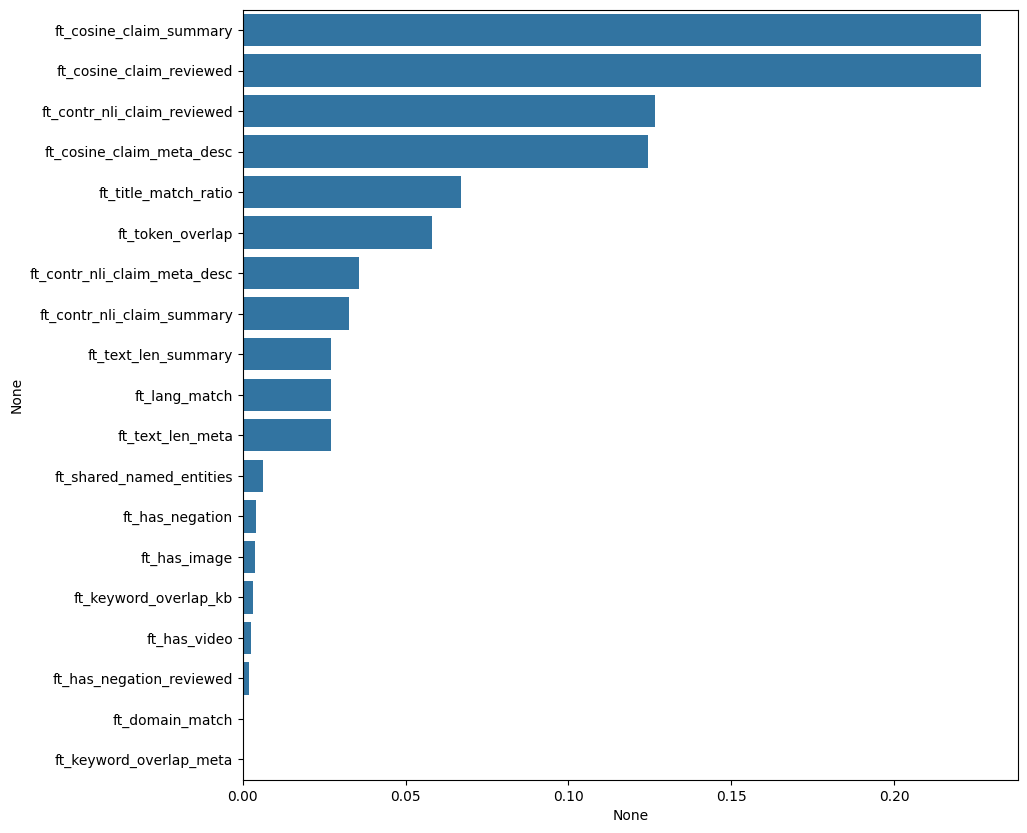

In [12]:
# Plot feature importances
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.show()

In [13]:
y_test = df_test["similarity"]
X_test = df_test.drop(columns=["similarity"])
y_pred_test = model.predict(X_test)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       0.90      0.95      0.93       284
           1       0.85      0.72      0.78       106

    accuracy                           0.89       390
   macro avg       0.88      0.84      0.85       390
weighted avg       0.89      0.89      0.89       390



In [14]:
import joblib
joblib.dump(model, "nbs/other/ml_classifier/rf.pkl")

['nbs/other/ml_classifier/rf.pkl']

In [15]:
json.dump(cv.best_params_, open("nbs/other/ml_classifier/params.json", "w"))

In [16]:
model.predict_proba(X_train)[:, 1]

array([0.9575    , 0.81998106, 0.25403423, ..., 0.0040813 , 0.00317871,
       0.00365129])